# CSI4142 Assignment 2
Jonathan Cojita, Lucas Gavura

## Part 2: Imputation
Jonathan Cojita

In [48]:
#Imports needed libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import numpy as np
from collections import defaultdict

In [49]:
#Import dataset and preview
path = kagglehub.dataset_download(
    "yashdev01/spotify-tracks-dataset"
)

df = pd.read_csv(f"{path}/spotify-tracks-dataset.csv")
print(df.head())

   Unnamed: 0.1  Unnamed: 0                track_id                 artists  \
0             0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1             1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2             2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3             3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4             4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       1496

### 2.1:
**Type of Imputation**:
**Description of Imputation**:

**Type of Missing Data Simulated**:
**Attrtibute Affected**:
**How Missing Data is Simulated**:


speechiness - MCAR (Median)
Genre - MAR (Similarity Based)
Popularity - MCAR (Regression)


In [50]:
#Simulate MCAR over genre column
missing_rate = 0.1
n_missing = int(len(df) * missing_rate)
missing_indices = np.random.choice(df.index, n_missing, replace=False)

# Save original values before introducing NaN so we can evaluate imputation later
original_genre_values = df.loc[missing_indices, 'speechiness'].copy()

df.loc[missing_indices, 'speechiness'] = np.nan

#Print missing value row sample (Print track, artist, and genre)
print(df[df['speechiness'].isna()].head()[['track_name', 'artists', 'speechiness']])

                track_name                   artists  speechiness
10    Give Me Your Forever              Zack Tabudlo          NaN
16   ily (i love you baby)      Andrew Foy;Renee Foy          NaN
34            Party of One  Brandi Carlile;Sam Smith          NaN
47  You and Me on the Rock     Brandi Carlile;Lucius          NaN
59      What's Left of You          Chord Overstreet          NaN


In [51]:
#Calculate the speachiness mean
mean_speechiness = df['speechiness'].mean()
print(f"Mean speechiness: {mean_speechiness}")

Mean speechiness: 0.08474483235867447


In [52]:
#Impute missing values with mode
imputed_indices = df[df['speechiness'].isna()].index
df['speechiness'] = df['speechiness'].fillna(mean_speechiness)

#Print the rows that were just imputed to confirm
print(f"Imputed {len(imputed_indices)} rows")
print(df.loc[imputed_indices, ['track_name', 'artists', 'speechiness']].head())

Imputed 11400 rows
                track_name                   artists  speechiness
10    Give Me Your Forever              Zack Tabudlo     0.084745
16   ily (i love you baby)      Andrew Foy;Renee Foy     0.084745
34            Party of One  Brandi Carlile;Sam Smith     0.084745
47  You and Me on the Rock     Brandi Carlile;Lucius     0.084745
59      What's Left of You          Chord Overstreet     0.084745


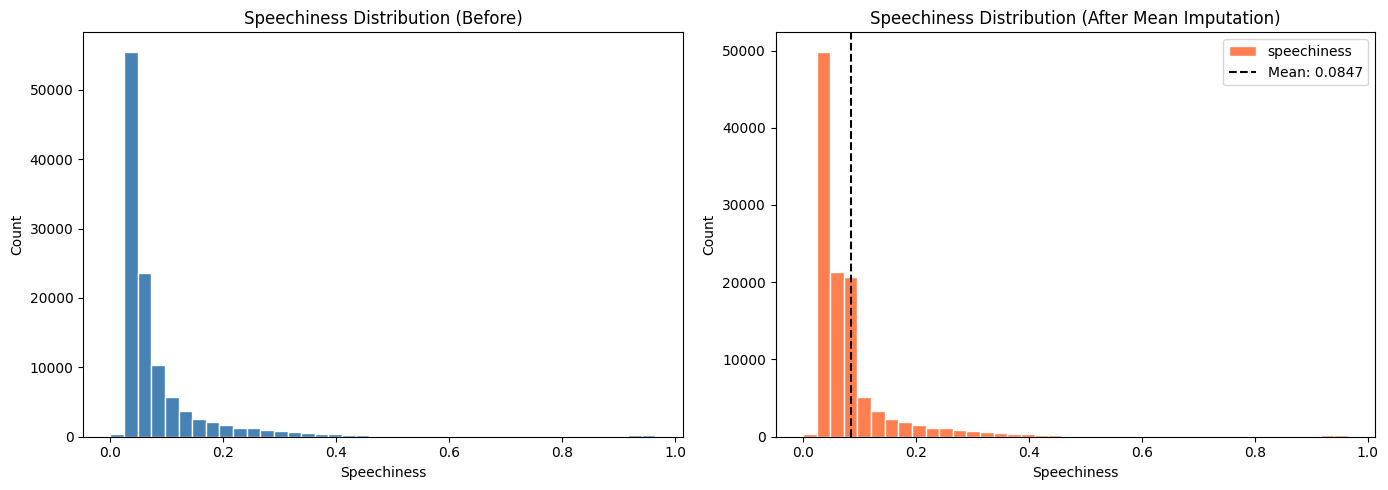

In [55]:
#Plot speechiness distribution before vs after imputation (full dataset)

# Reconstruct full "before" distribution: original values for imputed rows + untouched rows
before_full = pd.concat([
    original_genre_values,
    df.loc[~df.index.isin(missing_indices), 'speechiness']
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_full.plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Speechiness Distribution (Before)')
axes[0].set_xlabel('Speechiness')
axes[0].set_ylabel('Count')

df['speechiness'].plot(kind='hist', bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].axvline(mean_speechiness, color='black', linestyle='--', label=f'Mean: {mean_speechiness:.4f}')
axes[1].set_title('Speechiness Distribution (After Mean Imputation)')
axes[1].set_xlabel('Speechiness')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()